# Forecasting the US Treasury Yield Curve: Diebold-Li vs Random Walk, 1982–2026

Do the three Nelson-Siegel factors help to forecast the yield curve? This notebook applies the method of Diebold and Li (2006): an AR(1) model for each factor, used to forecast the curve 1, 6 and 12 months ahead. The forecasts are evaluated out of sample from 2000 to 2026 against the random walk ("yields do not move"), with a Diebold-Mariano test, an analysis by period and a robustness check with a rolling window.

**Contents:** 1. Setup · 2. Parameters · 3. Functions · 4. Data · 5. The Diebold-Li model · 6. Out-of-sample test · 7. Results by period · 8. Figures · 9. Robustness check · 10. Key findings

## 1. Setup

In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from fredapi import Fred
from nelson_siegel_svensson.calibrate import betas_ns_ols
from scipy import stats
from matplotlib.colors import TwoSlopeNorm

load_dotenv()
fred = Fred(api_key=os.getenv("FRED_API_KEY"))

## 2. Parameters

In [27]:
# FRED code -> maturity in years
SERIES = {"DGS3MO": 0.25, "DGS6MO": 0.5, "DGS1": 1, "DGS2": 2,
          "DGS3": 3, "DGS5": 5, "DGS7": 7, "DGS10": 10}

# λ fixed as in Diebold & Li (2006): 0.0609 in months, i.e. 0.7308 in years
LAMBDA = 0.7308
TAU = 1 / LAMBDA                      # the library uses τ = 1/λ
t = np.array(list(SERIES.values()))   # maturities in years, in column order

HORIZONS = [1, 6, 12]                 # forecast horizons, in months
OOS_START = "2000-01-01"              # first forecast target of the out-of-sample test
ROLLING_WINDOW = 120                  # 10 years of monthly data, for the robustness check

PERIODS = {
    "2000–2007 (pre-crisis)": ("2000-01-01", "2007-12-31"),
    "2008–2015 (crisis and zero rates)": ("2008-01-01", "2015-12-31"),
    "2016–2021 (normalisation and Covid)": ("2016-01-01", "2021-12-31"),
    "2022–2026 (hiking cycle)": ("2022-01-01", "2026-12-31"),
}

## 3. Functions

**Data and Nelson-Siegel fit**

In [28]:
def download_month_end(series, obs_start="1982-01-01"):
    """Download Treasury yields from FRED and keep the last available value of each month."""
    data = {}
    for series_id in series:
        try:
            data[series_id] = fred.get_series(series_id, observation_start=obs_start)
        except Exception as e:
            print(f"[ERROR] {series_id}: {e}")

    if not data:
        raise ValueError("No data downloaded.")

    month_end = pd.DataFrame(data).resample("ME").last().dropna()

    # Keep complete months only
    current_month = pd.Timestamp.today().to_period("M")
    return month_end[month_end.index.to_period("M") < current_month]


def fit_ns(y, tau=TAU):
    """Fit Nelson-Siegel (fixed λ) on one curve and return the curve and the fit error in basis points."""
    curve, _ = betas_ns_ols(tau, t, y)
    rmse_bp = np.sqrt(np.mean((y - curve(t)) ** 2)) * 100
    return curve, rmse_bp


def fit_all_months(yields, tau=TAU):
    """Fit Nelson-Siegel on every month and return the factors and the fit error."""
    rows = []
    for date, row in yields.iterrows():
        curve, rmse_bp = fit_ns(row.values, tau)
        rows.append({
            "date": date,
            "beta0": curve.beta0,
            "beta1": curve.beta1,
            "beta2": curve.beta2,
            "rmse_bp": rmse_bp,
        })
    return pd.DataFrame(rows).set_index("date")

**Forecasting: Diebold-Li model, random walk and out-of-sample loop**

In [29]:
def fit_ar1_direct(series, h):
    """Estimate the direct h-step AR(1) of Diebold & Li: x(t+h) = c + phi * x(t)."""
    x = series.values
    X = np.column_stack([np.ones(len(x) - h), x[:-h]])
    y = x[h:]
    (c, phi), *_ = np.linalg.lstsq(X, y, rcond=None)
    return c, phi


def forecast_factors(factors_hist, h):
    """Forecast beta0, beta1 and beta2 h months ahead, using only the history passed in."""
    forecast = {}
    for col in ["beta0", "beta1", "beta2"]:
        c, phi = fit_ar1_direct(factors_hist[col], h)
        forecast[col] = c + phi * factors_hist[col].iloc[-1]
    return forecast


def ns_yields(beta0, beta1, beta2, maturities=t, lam=LAMBDA):
    """Turn Nelson-Siegel factors into yields at the given maturities."""
    m = np.asarray(maturities, dtype=float)
    slope = (1 - np.exp(-lam * m)) / (lam * m)
    curvature = slope - np.exp(-lam * m)
    return beta0 + beta1 * slope + beta2 * curvature


def run_oos_forecasts(yields, factors, horizons=HORIZONS, start=OOS_START, window=None):
    """Out-of-sample forecasts: Diebold-Li (AR(1) on factors) vs random walk.
    window=None uses an expanding window; an integer uses a rolling window of that many months."""
    dates = yields.index
    first_origin = dates.get_indexer([pd.Timestamp(start)], method="bfill")[0] - 1
    rows = []
    for h in horizons:
        for i in range(first_origin, len(dates) - h):
            first = 0 if window is None else max(0, i + 1 - window)
            history = factors.iloc[first: i + 1]                 # only data known at the forecast date
            dl = ns_yields(**forecast_factors(history, h))
            rw = yields.iloc[i].values                           # random walk: yields do not move
            actual = yields.iloc[i + h].values
            for model, fc in [("Diebold-Li", dl), ("Random walk", rw)]:
                rows.append(pd.DataFrame({
                    "origin": dates[i], "target": dates[i + h], "h": h, "model": model,
                    "maturity": yields.columns, "error_bp": (fc - actual) * 100,
                }))
    return pd.concat(rows, ignore_index=True)


def rmse_table(oos):
    """RMSE in basis points by horizon, model and maturity."""
    return (oos.assign(sq=oos["error_bp"] ** 2)
               .groupby(["h", "model", "maturity"])["sq"].mean().pow(0.5)
               .unstack("maturity")[list(SERIES)])

**Evaluation: Diebold-Mariano test and results by period**

In [30]:
def diebold_mariano(e1, e2, h):
    """Diebold-Mariano test on squared errors, with the Harvey-Leybourne-Newbold correction.
    A positive statistic means model 1 is less accurate. Returns (statistic, two-sided p-value)."""
    d = np.asarray(e1) ** 2 - np.asarray(e2) ** 2
    T = len(d)
    d_bar = d.mean()
    dc = d - d_bar

    # Newey-West long-run variance with h - 1 lags (h-step forecasts overlap)
    lrv = np.sum(dc ** 2) / T
    for k in range(1, h):
        lrv += 2 * (1 - k / h) * np.sum(dc[k:] * dc[:-k]) / T

    dm = d_bar / np.sqrt(lrv / T)
    stat = dm * np.sqrt((T + 1 - 2 * h + h * (h - 1) / T) / T)
    p_value = 2 * stats.t.sf(abs(stat), df=T - 1)
    return stat, p_value


def dm_tables(oos):
    """Run the Diebold-Mariano test for each horizon and maturity (Diebold-Li vs random walk)."""
    rows = []
    for (h, maturity), group in oos.groupby(["h", "maturity"]):
        errors = group.pivot(index="target", columns="model", values="error_bp")
        stat, p_value = diebold_mariano(errors["Diebold-Li"], errors["Random walk"], h)
        rows.append({"h": h, "maturity": maturity, "stat": stat, "p_value": p_value})
    dm = pd.DataFrame(rows)
    stat_table = dm.pivot(index="h", columns="maturity", values="stat")[list(SERIES)].round(2)
    p_table = dm.pivot(index="h", columns="maturity", values="p_value")[list(SERIES)].round(3)
    return stat_table, p_table


def by_period(oos):
    """RMSE ratio and mean error (bias) by period and horizon, pooled across maturities."""
    rows = []
    for name, (start, end) in PERIODS.items():
        sub = oos[(oos["target"] >= start) & (oos["target"] <= end)]
        for h, group in sub.groupby("h"):
            rmse_m = group.groupby("model")["error_bp"].apply(lambda e: np.sqrt(np.mean(e ** 2)))
            bias_m = group.groupby("model")["error_bp"].mean()
            rows.append({
                "period": name, "h": h,
                "RMSE ratio (DL / RW)": rmse_m["Diebold-Li"] / rmse_m["Random walk"],
                "DL mean error (bp)": bias_m["Diebold-Li"],
                "RW mean error (bp)": bias_m["Random walk"],
            })
    return pd.DataFrame(rows).set_index(["period", "h"]).round(2)

**Figures**

In [31]:
def plot_ratio_heatmap(ratio, fig_num=1):
    """Heatmap of RMSE ratios (Diebold-Li / random walk): red = random walk better, blue = Diebold-Li better."""
    fig, ax = plt.subplots(figsize=(10, 3.5), dpi=200)
    norm = TwoSlopeNorm(vmin=0.8, vcenter=1.0, vmax=1.25)
    im = ax.imshow(ratio.values, cmap="RdBu_r", norm=norm, aspect="auto")

    for i in range(ratio.shape[0]):
        for j in range(ratio.shape[1]):
            ax.text(j, i, f"{ratio.values[i, j]:.2f}", ha="center", va="center", fontsize=9)

    ax.set_xticks(range(ratio.shape[1]), ["3M", "6M", "1Y", "2Y", "3Y", "5Y", "7Y", "10Y"])
    ax.set_yticks(range(ratio.shape[0]), [f"{h} month{'s' if h > 1 else ''}" for h in ratio.index])
    ax.set_xlabel("Maturity (years)")
    ax.set_ylabel("Forecast horizon")
    fig.colorbar(im, ax=ax, label="RMSE ratio (Diebold-Li / random walk)")
    ax.set_title(f"Figure {fig_num}, Out-of-Sample RMSE Ratio, 2000–2026 (above 1 = random walk wins)")
    fig.tight_layout()
    return fig

    
def plot_forecasts_vs_actual(oos, yields, maturity="DGS10", h=12, fig_num=2):
    """Plot the actual yield against the Diebold-Li and random walk forecasts made h months earlier."""
    sub = oos[(oos["h"] == h) & (oos["maturity"] == maturity)]
    actual = yields[maturity]

    fig, ax = plt.subplots(figsize=(12, 5), dpi=200)
    ax.plot(actual.loc[sub["target"].min():].index, actual.loc[sub["target"].min():], color="black", lw=1.5, label="Actual")
    for model, color in [("Diebold-Li", "tab:red"), ("Random walk", "tab:blue")]:
        m = sub[sub["model"] == model].set_index("target")
        forecast = actual.loc[m.index] + m["error_bp"] / 100            # forecast = actual + error
        ax.plot(forecast.index, forecast, color=color, lw=1, alpha=0.8, label=f"{model} forecast ({h} months ahead)")

    for start, end in PERIODS.values():
        ax.axvline(pd.Timestamp(start), color="grey", ls=":", lw=1)
    ax.set_xlabel("Date")
    ax.set_ylabel("Yield (%)")
    ax.set_title(f"Figure {fig_num}, {maturity}: Actual vs Forecasts Made {h} Months Earlier")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return fig


def plot_ratio_by_period(periods_table, fig_num=3):
    """Bar chart of the RMSE ratio by period and horizon."""
    table = periods_table["RMSE ratio (DL / RW)"].unstack("h")
    table.index = [p.replace(" (", "\n(") for p in table.index]       # wrap long period names
    fig, ax = plt.subplots(figsize=(11, 4.5), dpi=200)
    table.plot(kind="bar", ax=ax, rot=0, color=["#9ecae1", "#4292c6", "#08519c"])
    ax.axhline(1, color="black", lw=1, ls="--")
    ax.set_xlabel("")
    ax.set_ylabel("RMSE ratio (Diebold-Li / random walk)")
    ax.set_title(f"Figure {fig_num}, Forecast Accuracy by Period (below 1 = Diebold-Li wins)")
    ax.set_ylim(0, 1.6)
    ax.legend(title="Horizon (months)", loc="upper center", ncol=3)
    ax.grid(alpha=0.3, axis="y")
    fig.tight_layout()
    return fig

## 4. Data: end-of-month yields and Nelson-Siegel factors

Eight Treasury yields from FRED, keeping the last available value of each month: what an investor actually observes at month end, without the smoothing of monthly averages. The Nelson-Siegel factors are then fitted every month with a fixed λ.

In [32]:
yields = download_month_end(SERIES)
factors = fit_all_months(yields)

print(yields.shape, factors.shape)
yields.tail(3)

(537, 8) (537, 4)


,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10
2026-07-31,3.83,3.98,4.08,4.28,4.34,4.45,4.59,4.75
2026-08-31,3.91,3.99,4.16,4.34,4.40,4.49,4.62,4.75
2026-09-30,4.20,4.33,4.54,4.88,5.00,5.09,5.19,5.29


## 5. The Diebold-Li model

Each factor follows a direct h-step AR(1): its value h months ahead equals c + φ × its current value, estimated by regressing the factor on its own value h months earlier. The forecast curve is rebuilt from the three forecast factors with the Nelson-Siegel formula. The coefficient φ measures persistence: close to 1, the factor moves slowly.

In [33]:
persistence = pd.DataFrame({
    f"φ (h = {h})": {col: fit_ar1_direct(factors[col], h)[1] for col in ["beta0", "beta1", "beta2"]}
    for h in HORIZONS
}).round(3)
persistence

,φ (h = 1),φ (h = 6),φ (h = 12)
beta0,0.986,0.919,0.862
beta1,0.972,0.805,0.570
beta2,0.944,0.718,0.527


In [34]:
f12 = forecast_factors(factors, 12)
illustration = pd.DataFrame({
    "Last observed": yields.iloc[-1].values,
    "Forecast in 12 months": ns_yields(**f12),
}, index=yields.columns).round(2)
illustration

,Last observed,Forecast in 12 months
DGS3MO,4.20,3.75
DGS6MO,4.33,3.85
DGS1,4.54,4.02
DGS2,4.88,4.29
DGS3,5.00,4.48
DGS5,5.09,4.71
DGS7,5.19,4.84
DGS10,5.29,4.95


### Persistence of the factors and an illustrative forecast

| Factor | φ (h = 1) | φ (h = 6) | φ (h = 12) |
|--------|-----------|-----------|------------|
| β₀ (level) | 0.986 | 0.919 | 0.862 |
| β₁ (slope) | 0.972 | 0.805 | 0.570 |
| β₂ (curvature) | 0.944 | 0.718 | 0.527 |

The level is the most persistent factor (a shock takes about four years to fade by half), then the slope (about two years) and the curvature (about one year), the same ranking as in Diebold and Li (2006).

The illustrative 12-month forecast lowers the whole curve, more at the short end than at the long end. This is not an economic view: the AR(1) simply pulls each factor back toward its historical mean, with no information on the Fed or on current inflation. Both tables use all the data up to today: they describe the model, but cannot be used to evaluate it. The fair test is the out-of-sample exercise below.

## 6. Out-of-sample test (2000–2026)

From December 1999 onwards, at every month end, the model is estimated using past data only (expanding window), the curve is forecast 1, 6 and 12 months ahead, then the procedure moves forward one month. Errors are computed as forecast minus actual, in basis points, and compared with the random walk. The Diebold-Mariano test then checks whether the differences are statistically significant.

In [35]:
oos = run_oos_forecasts(yields, factors)
print(oos.shape)
oos.head()

(15152, 6)


,origin,target,h,model,maturity,error_bp
0,1999-12-31,2000-01-31,1,Diebold-Li,DGS3MO,-35.258088
1,1999-12-31,2000-01-31,1,Diebold-Li,DGS6MO,-38.552578
2,1999-12-31,2000-01-31,1,Diebold-Li,DGS1,-44.636527
3,1999-12-31,2000-01-31,1,Diebold-Li,DGS2,-44.337320
4,1999-12-31,2000-01-31,1,Diebold-Li,DGS3,-33.590315


In [36]:
rmse = rmse_table(oos)
rmse.round(1)

maturity        DGS3MO  DGS6MO   DGS1   DGS2   DGS3   DGS5   DGS7  DGS10
h  model                                                                
1  Diebold-Li     23.4    23.9   23.8   26.2   28.7   29.1   27.5   27.1
   Random walk    21.6    20.9   21.2   24.6   26.0   27.0   26.7   25.8
6  Diebold-Li     94.1    96.2   93.7   89.6   87.7   79.8   72.6   67.0
   Random walk    84.7    84.1   79.8   76.1   73.8   68.4   64.8   60.8
12 Diebold-Li    161.1   161.2  155.7  143.8  135.6  118.4  105.8   95.1
   Random walk   149.2   147.9  138.9  124.6  114.3   98.4   89.8   81.6

In [37]:
ratio = (rmse.xs("Diebold-Li", level="model") / rmse.xs("Random walk", level="model")).round(2)
ratio

maturity,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10
h,,,,,,,,
1,1.08,1.14,1.12,1.06,1.10,1.08,1.03,1.05
6,1.11,1.14,1.17,1.18,1.19,1.17,1.12,1.10
12,1.08,1.09,1.12,1.15,1.19,1.20,1.18,1.17


In [38]:
dm_stat, dm_p = dm_tables(oos)
display(dm_stat)
display(dm_p)

maturity,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10
h,,,,,,,,
1,2.35,4.52,3.98,3.60,3.77,3.31,1.72,3.07
6,2.44,2.50,2.89,3.06,3.18,2.98,2.59,2.78
12,0.99,1.03,1.35,1.64,1.92,2.19,2.24,2.53


maturity,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10
h,,,,,,,,
1,0.020,0.000,0.000,0.000,0.000,0.001,0.087,0.002
6,0.015,0.013,0.004,0.002,0.002,0.003,0.010,0.006
12,0.323,0.302,0.178,0.103,0.056,0.030,0.025,0.012


### Out-of-sample results: Diebold-Li vs random walk (2000–2026)

Forecasts are made every month from December 1999 onwards with an expanding window: at each date, the AR(1) coefficients are re-estimated using past data only, then the curve is forecast 1, 6 and 12 months ahead. The benchmark is the random walk: yields are expected not to move.

**The random walk wins everywhere.** The RMSE ratio (Diebold-Li / random walk) is above 1 for all 24 horizon-maturity pairs, from 1.03 to 1.20: Diebold-Li makes 3% to 20% larger errors. The gap is widest at 6 and 12 months for intermediate maturities (2 to 7 years), precisely where Diebold and Li reported their best results over their sample ending in 2000.

**Errors grow quickly with the horizon:** about 25 bp at 1 month, but 80 to 160 bp at 12 months for both methods. Forecasting the curve one year ahead remains very difficult.

**The difference is statistically significant.** A Diebold-Mariano test on squared errors, with Newey-West variance (to account for overlapping forecasts) and the Harvey-Leybourne-Newbold small-sample correction, gives a positive statistic in all 24 cases. 18 of them are significant at the 5% level: all 8 at 6 months, 7 of 8 at 1 month, and 3 of 8 at 12 months (the 5-, 7- and 10-year maturities). Diebold-Li is never significantly better than the random walk.

**Takeaway:** the forecasting success reported by Diebold and Li does not hold over 2000–2026. A simple AR(1) pulls each factor back toward its historical mean, which is a weakness in a period marked by a long decline in rates, zero interest rates and abrupt policy shifts.

## 7. Results by period

The 26 years are split into four regimes. For each one, the RMSE ratio shows whether the model loses everywhere, and the mean error (bias) shows in which direction it errs.

In [39]:
periods_table = by_period(oos)
periods_table

RMSE ratio (DL / RW)  \
period                              h                          
2000–2007 (pre-crisis)              1                   1.07   
                                    6                   1.16   
                                    12                  1.12   
2008–2015 (crisis and zero rates)   1                   1.15   
                                    6                   1.30   
                                    12                  1.38   
2016–2021 (normalisation and Covid) 1                   1.01   
                                    6                   0.93   
                                    12                  0.85   
2022–2026 (hiking cycle)            1                   1.05   
                                    6                   1.08   
                                    12                  1.08   

                                        DL mean error (bp)  RW mean error (bp)  
period                              h                                           
2000–2007 (pre-crisis)              1                 6.73                2.79  
                                    6                39.24               15.19  
                                    12               68.41               24.84  
2008–2015 (crisis and zero rates)   1                10.03                2.31  
                                    6                62.26               18.49  
                                    12              113.64               43.11  
2016–2021 (normalisation and Covid) 1                 0.96                0.56  
                                    6                 4.83                3.47  
                                    12                2.69                6.60  
2022–2026 (hiking cycle)            1               -10.30               -7.01  
                                    6               -60.61              -38.15  
                                    12             -120.87              -72.06

### Results by period: when and why the model loses

| Period | h | RMSE ratio (DL / RW) | DL mean error (bp) | RW mean error (bp) |
|--------|---|----------------------|--------------------|--------------------|
| 2000–2007 (pre-crisis) | 12 | 1.12 | +68.4 | +24.8 |
| 2008–2015 (crisis and zero rates) | 12 | 1.38 | +113.6 | +43.1 |
| 2016–2021 (normalisation and Covid) | 12 | 0.85 | +2.7 | +6.6 |
| 2022–2026 (hiking cycle) | 12 | 1.08 | −120.9 | −72.1 |

Errors are computed as forecast minus actual: a positive mean error means forecast yields were too high.

- **2000–2007:** the model loses and forecasts yields that are too high (+68 bp on average at 12 months). Rates were falling, and the AR(1) kept pulling them back toward a higher historical mean.
- **2008–2015:** its worst period (ratio up to 1.38, +114 bp bias at 12 months). Under zero interest rates, the model forecast month after month a rise in rates that never came.
- **2016–2021:** the only regime where it wins, with ratios of 0.93 at 6 months and 0.85 at 12 months and almost no bias. When rates oscillate around their mean, mean reversion becomes an asset.
- **2022–2026:** it loses again, but the bias reverses (−121 bp at 12 months): with a deeply inverted curve, the AR(1) pulled the slope back toward its historical mean and expected short-rate cuts that the Fed delivered much later. The random walk is also biased downward (−72 bp): the size of the hiking cycle surprised every simple forecast.

**Takeaway:** the model is built for a world where rates revert to their mean. It wins when they do and loses in trending regimes, the long decline until 2015 and the sharp rise since 2022, which dominated the 2000–2026 period.

## 8. Figures

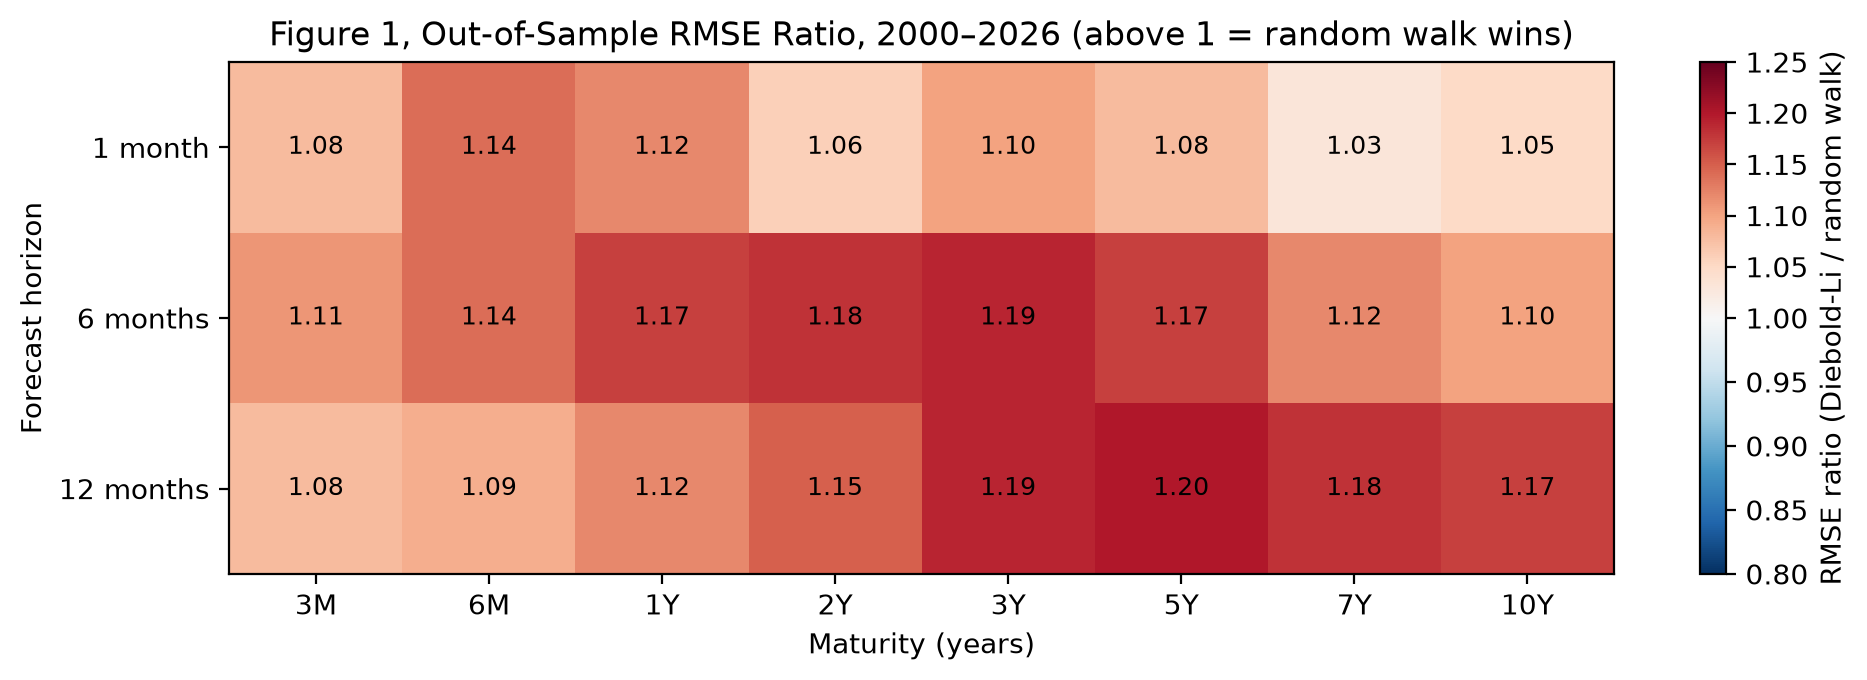

In [40]:
fig = plot_ratio_heatmap(ratio)
fig.savefig("assets/figure1_ratio_heatmap.png", bbox_inches="tight")
plt.show()

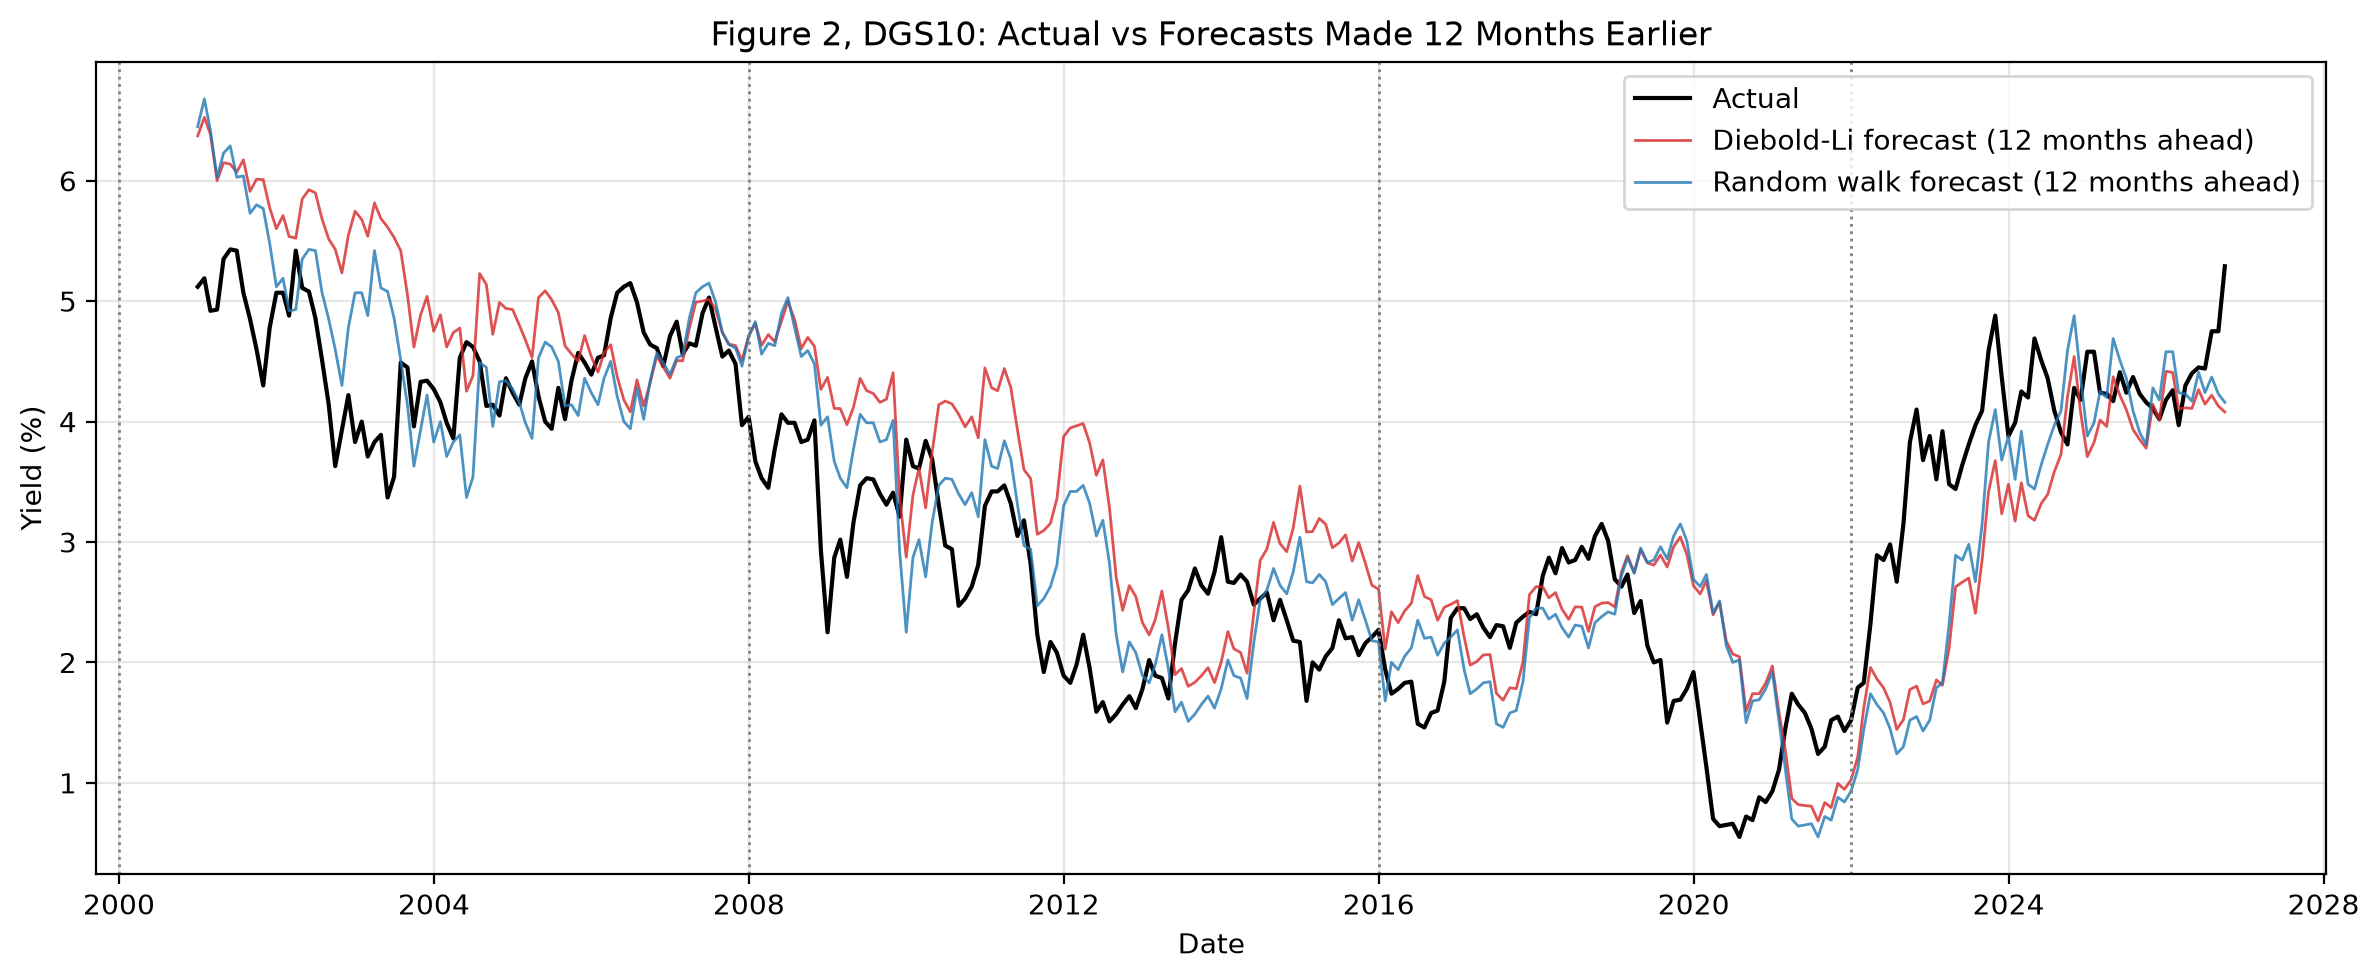

In [41]:
fig = plot_forecasts_vs_actual(oos, yields)
fig.savefig("assets/figure2_forecasts_vs_actual.png", bbox_inches="tight")
plt.show()

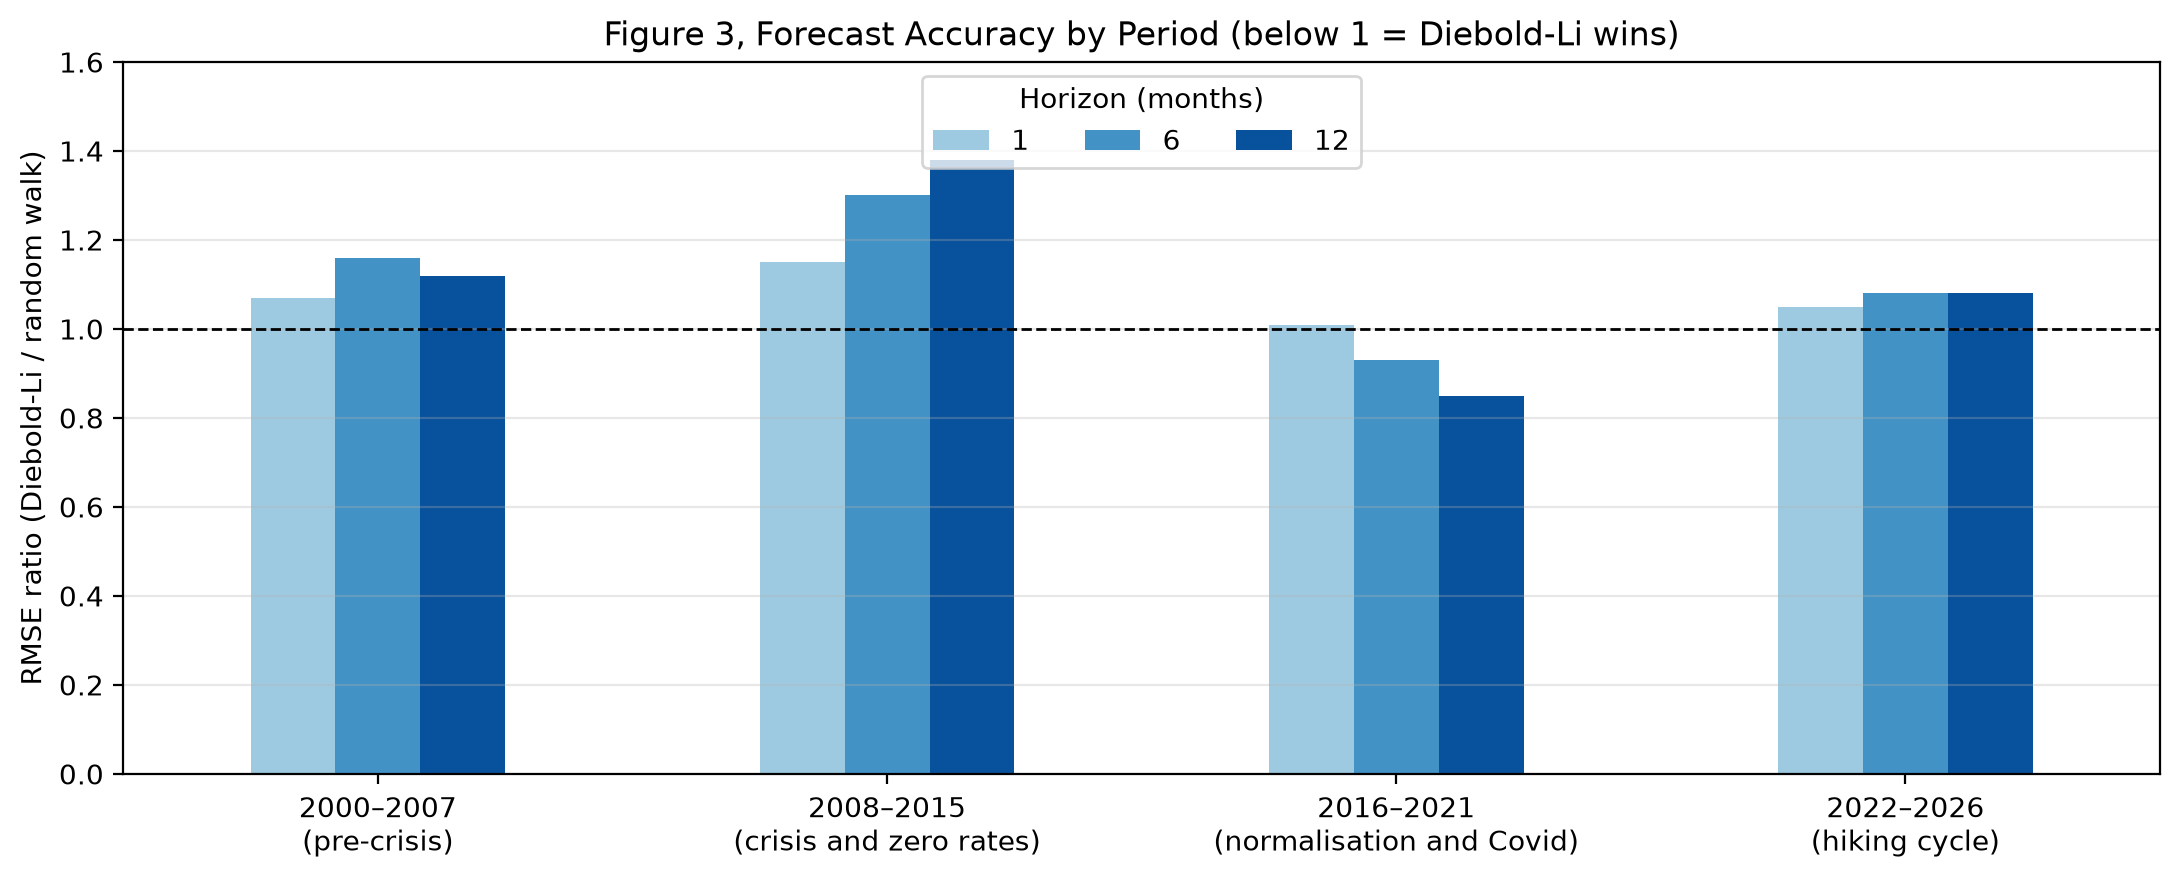

In [42]:
fig = plot_ratio_by_period(periods_table)
fig.savefig("assets/figure3_ratio_by_period.png", bbox_inches="tight")
plt.show()

### Visual summary (Figures 1 to 3)

- **Figure 1** shows the RMSE ratio for every horizon and maturity: all cells are red (the random walk wins), darker at 6 and 12 months for maturities of 2 to 10 years.
- **Figure 2** makes the bias visible on the 10-year yield: from 2002 to 2015, the Diebold-Li forecast sits mostly above the actual yield, especially in 2009–2012; in 2022–2024, it falls below. Both forecasts follow the actual yield with a one-year lag: neither anticipates the major turning points (2008, 2020, 2022).
- **Figure 3** isolates the only regime where Diebold-Li wins: 2016–2021, when rates oscillated around their mean.

## 9. Robustness check: a 10-year rolling window

Same out-of-sample test, but the AR(1) is estimated on the last 120 months only, so that its mean adapts to the recent regime.

In [43]:
oos_roll = run_oos_forecasts(yields, factors, window=ROLLING_WINDOW)

rmse_roll = rmse_table(oos_roll)
ratio_roll = (rmse_roll.xs("Diebold-Li", level="model") / rmse_roll.xs("Random walk", level="model")).round(2)
ratio_roll

maturity,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10
h,,,,,,,,
1,1.16,1.14,1.10,1.05,1.11,1.10,1.04,1.04
6,1.22,1.22,1.24,1.23,1.24,1.23,1.19,1.16
12,1.20,1.21,1.24,1.27,1.30,1.30,1.27,1.26


In [44]:
periods_roll = by_period(oos_roll)
window_comparison = pd.DataFrame({
    "Ratio, expanding": periods_table["RMSE ratio (DL / RW)"],
    "Ratio, rolling 10y": periods_roll["RMSE ratio (DL / RW)"],
    "Bias, expanding (bp)": periods_table["DL mean error (bp)"],
    "Bias, rolling 10y (bp)": periods_roll["DL mean error (bp)"],
})
window_comparison

Ratio, expanding  Ratio, rolling 10y  \
period                              h                                          
2000–2007 (pre-crisis)              1               1.07                1.06   
                                    6               1.16                1.22   
                                    12              1.12                1.29   
2008–2015 (crisis and zero rates)   1               1.15                1.18   
                                    6               1.30                1.36   
                                    12              1.38                1.35   
2016–2021 (normalisation and Covid) 1               1.01                1.11   
                                    6               0.93                1.30   
                                    12              0.85                1.36   
2022–2026 (hiking cycle)            1               1.05                1.01   
                                    6               1.08                1.05   
                                    12              1.08                1.08   

                                        Bias, expanding (bp)  \
period                              h                          
2000–2007 (pre-crisis)              1                   6.73   
                                    6                  39.24   
                                    12                 68.41   
2008–2015 (crisis and zero rates)   1                  10.03   
                                    6                  62.26   
                                    12                113.64   
2016–2021 (normalisation and Covid) 1                   0.96   
                                    6                   4.83   
                                    12                  2.69   
2022–2026 (hiking cycle)            1                 -10.30   
                                    6                 -60.61   
                                    12               -120.87   

                                        Bias, rolling 10y (bp)  
period                              h                           
2000–2007 (pre-crisis)              1                     8.86  
                                    6                    49.97  
                                    12                   99.74  
2008–2015 (crisis and zero rates)   1                    11.37  
                                    6                    65.94  
                                    12                  111.71  
2016–2021 (normalisation and Covid) 1                     1.24  
                                    6                    13.36  
                                    12                   22.25  
2022–2026 (hiking cycle)            1                    -8.82  
                                    6                   -57.30  
                                    12                 -125.50

In [45]:
dm_stat_roll, dm_p_roll = dm_tables(oos_roll)
display(dm_stat_roll)
display(dm_p_roll)

maturity,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10
h,,,,,,,,
1,3.98,5.19,3.71,3.11,3.91,3.70,2.23,2.22
6,4.29,4.02,3.80,3.52,3.42,2.92,2.46,2.42
12,2.32,2.16,2.26,2.37,2.57,2.82,2.79,2.83


maturity,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10
h,,,,,,,,
1,0.000,0.000,0.000,0.002,0.000,0.000,0.026,0.027
6,0.000,0.000,0.000,0.001,0.001,0.004,0.014,0.016
12,0.021,0.031,0.024,0.018,0.011,0.005,0.006,0.005


### Robustness check: a 10-year rolling window

**Hypothesis tested:** the model loses because its AR(1) pulls each factor toward a mean computed over the whole history since 1982, inflated by the high rates of the 1980s. A rolling window using only the last 10 years (120 months) should adapt the mean to the recent regime.

| Period | h | Ratio, expanding | Ratio, rolling 10y | Bias, expanding (bp) | Bias, rolling 10y (bp) |
|--------|---|------------------|--------------------|----------------------|------------------------|
| 2000–2007 | 12 | 1.12 | 1.29 | +68.4 | +99.7 |
| 2008–2015 | 12 | 1.38 | 1.35 | +113.6 | +111.7 |
| 2016–2021 | 12 | 0.85 | 1.36 | +2.7 | +22.3 |
| 2022–2026 | 12 | 1.08 | 1.08 | −120.9 | −125.5 |

**The hypothesis is rejected.** The rolling window does worse: RMSE ratios reach 1.30 (against 1.20 with the expanding window), all 24 Diebold-Mariano statistics are now significant at 5%, and the biases do not shrink. Even the mean of the previous decade stayed above the falling rates of the early 2000s and far above the zero floor of 2008–2015. The model also loses its only win, in 2016–2021.

**Why it does even worse:** with fewer observations, the AR(1) coefficient φ is estimated with more noise, and it is known to be biased downward in small samples. A lower φ means stronger mean reversion, hence forecasts even further from reality.

## 10. Key findings

| # | Finding | Evidence |
|---|---------|----------|
| 1 | **The random walk beats Diebold-Li out of sample** | RMSE ratio above 1 for all 24 horizon-maturity pairs over 2000–2026, from 1.03 to 1.20 (Figure 1) |
| 2 | **The difference is statistically significant** | Diebold-Mariano statistic positive in 24 of 24 cases and significant at 5% in 18; Diebold-Li is never significantly better |
| 3 | **Forecasting one year ahead is hard for everyone** | RMSE of about 25 bp at 1 month, but 80 to 160 bp at 12 months for both methods |
| 4 | **The model's weakness is mean reversion in trending regimes** | Mean error at 12 months: +68 bp in 2000–2007 and +114 bp in 2008–2015 (forecasts too high while rates fell or sat at zero), −121 bp in 2022–2026 (forecasts too low during the hiking cycle) |
| 5 | **It wins when rates revert to their mean** | 2016–2021 is the only regime where Diebold-Li beats the random walk: RMSE ratio 0.93 at 6 months and 0.85 at 12 months (Figure 3) |
| 6 | **No simple model anticipates turning points** | Both forecasts follow the 10-year yield with a one-year lag and miss 2008, 2020 and 2022 (Figure 2) |
| 7 | **The problem is mean reversion itself, not the choice of mean** | A 10-year rolling window does worse than the expanding window (ratios up to 1.30, 24 of 24 Diebold-Mariano tests significant at 5%): the less the model reverts to a mean, the better it forecasts |

**Takeaway:** the forecasting success reported by Diebold and Li (2006) on data up to 2000 does not hold over 2000–2026. The problem is not *which* mean the model reverts to, but mean reversion itself: the more the model pulls yields back toward a historical mean, the worse it forecasts. The random walk amounts to assuming φ = 1, no mean reversion at all; over 2000–2026, yields behaved almost like a random walk, which is why it wins.

## References

- Diebold, F. X. & Li, C. (2006). *Forecasting the Term Structure of Government Bond Yields*. Journal of Econometrics, 130(2), 337–364. [Free working paper (NBER)](https://www.nber.org/papers/w10048)
- Diebold, F. X. & Mariano, R. S. (1995). *Comparing Predictive Accuracy*. Journal of Business & Economic Statistics, 13(3), 253–263.
- Harvey, D., Leybourne, S. & Newbold, P. (1997). *Testing the Equality of Prediction Mean Squared Errors*. International Journal of Forecasting, 13(2), 281–291.
- Newey, W. K. & West, K. D. (1987). *A Simple, Positive Semi-Definite, Heteroskedasticity and Autocorrelation Consistent Covariance Matrix*. Econometrica, 55(3), 703–708.